In [131]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from typing import List,TypedDict,Annotated,Literal,Optional

In [132]:
df = pd.read_csv('D:/Data Analysis/Space Mission Analysis/Dataset/Space_Missions_Dataset.csv')
df['Launch_Year'] = df['Launch_Date'].str.split("-").str[0]

In [133]:
df['Mission_Name'].value_counts()

Mission_Name
CRS-10                          2
Crew-7                          2
Mars Express                    2
CRS-30                          2
CRS-25                          2
                               ..
CNES Sun/Solar Mission 3532     1
NASA Deep Space Mission 3533    1
CNSA Sun/Solar Mission 3534     1
DLR Mars Mission 3535           1
CNSA Sun/Solar Mission 10500    1
Name: count, Length: 10477, dtype: int64

In [134]:
df.columns

Index(['Mission_ID', 'Mission_Name', 'Agency', 'Country_Region', 'Agency_Type',
       'Program_Type', 'Mission_Category', 'Sub_Category', 'Launch_Date',
       'End_Date', 'Duration', 'Launch_Vehicle', 'Launch_Site', 'Status',
       'Mission_Phase', 'Crew_Type', 'Crew_Members', 'Destination',
       'Objective', 'Key_Achievement', 'Cost_USD_Million', 'Partner_Agencies',
       'Data_Returned', 'Failure_Reason', 'Mission_Outcome_Detail',
       'Reference_URL', 'Launch_Year'],
      dtype='object')

In [135]:
def MissionnSearch1(m1):
    df2 = df[df['Mission_Name'] == m1].iloc[0]
    country_reg = df2['Country_Region']

    l1 = df2['Launch_Year']

    d1= df2['Destination']

    a1 = df2['Agency']

    b1 = df2['Cost_USD_Million']

    t1 = df2['Duration']

    agency_type1 = df2['Agency_Type']

    launch1 = df2['Launch_Vehicle']

    s1 = df2['Status']

    mission_cat1 = df2['Mission_Category']

    ach1 = df2['Key_Achievement']

    obj1 = df2['Objective']

    return {
        'mission_name': m1,
        'Country Region': country_reg,
        'Launch Vehicle': launch1,
        'Agency Type': agency_type1,
        'Mission Category': mission_cat1,
        'Status': s1,
        'Duration': t1,
        'Agency': a1,
        'Launch Year': l1,
        'Destination': d1,
        'Budget': b1,
        'Achievement': ach1,
        'Objective': obj1
    }

In [136]:
m1 = "Mars Express"
print(MissionnSearch1(m1))

{'mission_name': 'Mars Express', 'Country Region': 'USA', 'Launch Vehicle': 'Falcon 9', 'Agency Type': 'Government', 'Mission Category': 'Moon', 'Status': 'Success', 'Duration': '359 days', 'Agency': 'NASA', 'Launch Year': '2015', 'Destination': 'Moon', 'Budget': 12495.7, 'Achievement': 'Confirmed presence of subsurface water', 'Objective': 'Jupiter moon subsurface ocean investigation'}


In [137]:
from dotenv import load_dotenv
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults

In [138]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
)

In [139]:
# from tavily import TavilyClient
# from langchain_core.tools import tool

# client = TavilyClient()

# # @tool
# def scrape_url(url: str) -> str:
#     """Fetch and return the text content of a given URL."""
#     result = client.extract(urls=[url])
#     return result["results"][0]["raw_content"]

In [140]:
# print(scrape_url('https://en.wikipedia.org/wiki/Aryabhata_(satellite)'))

In [141]:
tool =TavilySearchResults(max_results=2)
results = tool.invoke({"query": 'Aryabhata mission'})
results

[{'title': 'Aryabhata (satellite) - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/Aryabhata_(satellite)',
  'content': '|  |  |\n --- |\n| Aryabhata, India\'s first indigenously built satellite | |\n|  | |\n| Mission type | Astrophysics |\n| Operator | ISRO |\n| COSPAR ID | 1975-033A Edit this at Wikidata |\n| SATCAT no. | 7753 |\n| Mission duration | 5 years, 11 months (Experiments ended during 5th day in orbit) |\n|  | |\n|  | |\n| Spacecraft properties | |\n| Manufacturer | ISRO |\n| Launch mass | 360 kg (790 lb) |\n| Dimensions | 1.4 × 1.4 m (4.6 × 4.6 ft) |\n| Power | 46 watts |\n|  | |\n|  | |\n| Start of mission | |\n| Launch date | 19 April 1975, 07:30 (1975-04-19UTC07:30Z) UTC |\n| Rocket | Kosmos-3M |\n| Launch site | Kapustin Yar 107/2") |\n| Contractor | Yuzhnoye |\n|  | |\n|  | |\n| End of mission | |\n| Last contact | March 1981 (1981-04) |\n| Decay date | 10 February 1992 |\n|  | |\n|  | |\n| Orbital parameters | | [...] On 19 April 1975, the satellite\'s 96.46-min

In [142]:
# def web_search(query:str):
#     tool = TavilySearchResults(max_results=2)
#     results = tool.invoke({"query": query})

#     normalized : List[dict] = []
#     for r in results or []:
#         normalized.append(
#             {
#                 "title": r.get("title") or "",
#                 "url": r.get("url") or  "",
#                 "content": r.get("content") or ""
#             }
#         )

#     return normalized

In [143]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate(
    template = """
        You are an expert in Space exploration mission. Your role is to write education and informative blogs based on the context provided and web search information provided to you.
        context: {context}
        web_results: {web_results}

        The blog should be in 300-500 words with section divided and explained clearly.
    """
)

In [144]:
import operator
from typing import List,TypedDict,Annotated,Literal,Optional

from pydantic import Field,BaseModel
from langgraph.graph import START,END,StateGraph
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults

In [145]:
class Plan(BaseModel):
    title: str
    summary: str
    sections: List[str]
    key_points : List[str]
    reference_urls : List[str]

In [146]:
class State(TypedDict):
    query: str
    mission_data : dict
    reference_urls: List[str]
    scraped_content: List[str]
    plan: Plan
    blog : str

In [147]:
def missionnsearch(state: State):

    m1 = state["query"]

    df2 = df[df["Mission_Name"] == m1].iloc[0]

    return {
        "mission_data": {
            "mission_name": m1,
            "Country Region": df2["Country_Region"],
            "Launch Vehicle": df2["Launch_Vehicle"],
            "Agency Type": df2["Agency_Type"],
            "Mission Category": df2["Mission_Category"],
            "Status": df2["Status"],
            "Duration": df2["Duration"],
            "Agency": df2["Agency"],
            "Launch Year": df2["Launch_Year"],
            "Destination": df2["Destination"],
            "Budget": df2["Cost_USD_Million"],
            "Achievement": df2["Key_Achievement"],
            "Objective": df2["Objective"],
        }
    }

In [148]:
PLANNING_SYSTEM = """
You are an expert technical blog planning agent specializing in space missions.

Your task is to analyze the provided mission information and any reference content, then create a structured plan for an educational blog.

The blog should be written for students, educators, and space enthusiasts.

Guidelines:

- Generate an engaging and descriptive blog title.
- Create a logical sequence of sections that tells the story of the mission.
- Identify the most important facts that must be covered in the blog.
- Use the provided reference URLs to support the content whenever applicable.
- Prioritize the provided mission information over external references.
- Do not invent facts or include information not supported by the provided content.
- Focus on explaining:
    • Why the mission was undertaken.
    • The mission objectives.
    • Technologies and launch vehicle.
    • Major events during the mission.
    • Key achievements.
    • Scientific and historical impact.
    • Interesting facts for readers.

Return ONLY the structured plan according to the provided schema.
Do not write the actual blog.
"""


def planner_node(state: State):

    planner = llm.with_structured_output(Plan)

    mission_data = state["mission_data"]
    reference_urls = state["reference_urls"]
    scraped_content = state["scraped_content"]

    plan = planner.invoke(
        [
            SystemMessage(content=PLANNING_SYSTEM),
            HumanMessage(
                content=f"""
                Mission Information:
                {mission_data}
                {scraped_content}

                Reference URLs:
                {reference_urls}

                Create a structured plan for writing a comprehensive educational blog about this mission.
                """
            ),
        ]
    )

    return {
        "plan": plan
    }

In [149]:
def web_search(state: State):

    query = state["query"]

    tool = TavilySearchResults(max_results=2)

    results = tool.invoke({"query": query})

    normalized: List[str] = []

    for r in results or []:
        url = r.get("url")

        if url and url not in normalized:
            normalized.append(url)

    return {
        "reference_urls": normalized
    }
    

In [150]:
from typing import List
from tavily import TavilyClient

client = TavilyClient()

def scrape_urls(state: State):

    urls = state["reference_urls"]

    result = client.extract(urls=urls)

    content: List[str] = []

    for r in result.get("results", []):
        raw_content = r.get("raw_content")

        if raw_content:
            content.append(raw_content)

    return {
        "scraped_content": content
    }

In [151]:
def context_compression(state: State):
    MAX_WORDS = 1200
    scraped_content = state["scraped_content"]
    compressed = []

    for doc in scraped_content:
        words = doc.split()
        compressed.append(" ".join(words[:MAX_WORDS]))

    return {
        "scraped_content": compressed
    }

In [152]:
WRITER_SYSTEM = """
You are an expert aerospace writer and educator.

Your task is to write a comprehensive, engaging, and factually accurate blog about the given space mission.

Instructions:

- Follow the provided blog plan exactly.
- Use the mission information as the primary source of truth.
- Use the scraped reference content only to enrich explanations and provide additional historical or scientific context.
- Never contradict the provided mission data.
- Do not invent facts. If information is missing, simply omit it.
- Write for students, educators, and space enthusiasts.
- Use clear and engaging language.
- Explain technical concepts in simple terms whenever possible.
- Include informative headings for each section.
- Maintain a logical flow from introduction to conclusion.
- Highlight:
    - Mission objectives
    - Historical background
    - Launch vehicle and technology
    - Mission timeline
    - Key achievements
    - Scientific discoveries
    - Long-term impact
    - Interesting facts
- End with a short conclusion summarizing the mission's significance.
- Finally add a "References" section listing the provided reference URLs.

Return only the completed blog in Markdown format.
"""

In [153]:

def blog_writer(state: State):

    topic = state["query"]
    mission_data = state["mission_data"]
    scraped_content = state["scraped_content"]
    plan = state["plan"]
    reference_urls = state["reference_urls"]

    response = llm.invoke(
        [
            SystemMessage(content=WRITER_SYSTEM),
            HumanMessage(
                content=f"""
                    Mission:
                    {topic}

                    Blog Plan:
                    {plan}

                    Mission Information:
                    {mission_data}

                    Reference Content:
                    {chr(10).join(scraped_content)}

                    Reference URLs:
                    {chr(10).join(reference_urls)}
            """
            ),
        ]
    )

    return {
        "blog": response.content
    }

    

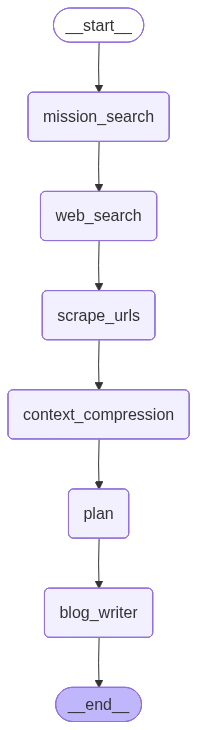

In [154]:
g = StateGraph(State)
g.add_node("mission_search",missionnsearch)
g.add_node("web_search",web_search)
g.add_node("scrape_urls",scrape_urls)
g.add_node("plan",planner_node)
g.add_node("blog_writer",blog_writer)
g.add_node("context_compression",context_compression)

g.add_edge(START,"mission_search")
g.add_edge("mission_search","web_search")
g.add_edge("web_search","scrape_urls")
g.add_edge("scrape_urls","context_compression")
g.add_edge("context_compression","plan")
g.add_edge("plan","blog_writer")
g.add_edge("blog_writer",END)

app = g.compile()
app


In [155]:
def chat(query:str):
    result = app.invoke(
        {
            "query": query
        }
    )

    return {
        "mission_data": result["mission_data"],
        "blog": result["blog"],
        "reference_urls": result["reference_urls"]
    }

In [156]:
chat("Mars Express")

{'mission_data': {'mission_name': 'Mars Express',
  'Country Region': 'USA',
  'Launch Vehicle': 'Falcon 9',
  'Agency Type': 'Government',
  'Mission Category': 'Moon',
  'Status': 'Success',
  'Duration': '359 days',
  'Agency': 'NASA',
  'Launch Year': '2015',
  'Destination': 'Moon',
  'Budget': 12495.7,
  'Achievement': 'Confirmed presence of subsurface water',
  'Objective': 'Jupiter moon subsurface ocean investigation'},
 'blog': '# NASA’s Moon Quest: The 2015 *Mars Express* Mission – From Launch to Sub‑Surface Water Discovery  \n\n*An engaging, student‑friendly walkthrough of NASA’s 2015 Moon‑bound mission “Mars\u202fExpress,” its daring goal to probe a hidden ocean on a Jupiter moon, the Falcon\u202f9 launch, the 359‑day cruise, the breakthrough confirmation of subsurface water, and its lasting scientific legacy.*\n\n---\n\n## 1. Introduction – Setting the Stage for a Moon Mission Named *Mars Express*\n\nIn 2015 NASA announced a bold new mission with a surprising name: **Mars\